# Cone-linearized annulus-disc analysis
**The experiment.** Every natural-image annulus patch is shown three ways, interleaved:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform annulus at the linear-equivalent intensity (patch averaged over the surround RF) |
| `linConeIntensity` / `lin cone intensity` | uniform annulus at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

Comparing image against each annulus asks how much of the cell's preference for the real image
survives when the averaging happens in cone-response space instead of intensity space. The
measure is the nonlinearity index per patch, exactly as `computeNLI` defines it:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

set to zero when neither response clears a recording-mode threshold.


In [2]:
import contextlib
import io
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.59 s


## 1. Find annulus-disc experiment dates and cells

The fast table shows every available `LinearEquivalentAnnulus` cell × resolved
`onlineAnalysis` × numeric FilterWheel combination, together with the short cell type and
protocol name. Its values can be copied directly into Section 2. Detailed raw response
loading is deferred until one condition is selected.


In [2]:
ANNULUS_PROTOCOLS = ('LinearEquivalentAnnulus',)
PROTOCOL_LABEL = 'cone-linearized annulus disc'

protocol_blocks = led.find_blocks(protocols=ANNULUS_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    protocol_blocks = led.check_series_resistance(
        protocol_blocks, show=False, sample_series_resistance=True)
protocol_cells = (protocol_blocks[[
    'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'filter_wheel_ndf', 'protocol']]
    .drop_duplicates()
    .sort_values(['exp_name', 'cell_label', 'onlineAnalysis',
                  'filter_wheel_ndf', 'protocol'])
    .reset_index(drop=True))
protocol_cells.insert(
    0, 'date_index', pd.factorize(protocol_cells['exp_name'], sort=False)[0] + 1)
print(f'{PROTOCOL_LABEL}: {len(protocol_cells)} available conditions across '
      f'{protocol_cells.exp_name.nunique()} experiments')
sc.scroll_table(protocol_cells, height=420, num_cols=('filter_wheel_ndf',))


cone-linearized annulus disc: 136 available conditions across 38 experiments


date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,filter_wheel_ndf,protocol
1,2022-07-05_G,Cell2,ON-parasol,exc,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell4,OFF-parasol,extracellular,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell5,OFF-parasol,extracellular,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell6,ON-parasol,extracellular,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell7,ON-parasol,extracellular,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell8,OFF-parasol,extracellular,0.0,LinearEquivalentAnnulus
1,2022-07-05_G,Cell9,ON-parasol,extracellular,0.0,LinearEquivalentAnnulus
2,2022-07-12_G,Cell1,ON-parasol,extracellular,0.0,LinearEquivalentAnnulus
2,2022-07-12_G,Cell2,OFF-parasol,extracellular,0.0,LinearEquivalentAnnulus
2,2022-07-12_G,Cell3,ON-parasol,extracellular,0.0,LinearEquivalentAnnulus


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:420px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>filter_wheel_ndf</th><th>protocol</th></tr></thead><tbody><tr><td>1</td><td>2022-07-05_G</td><td>Cell2</td><td>ON-p

## 2. Analyze one cell condition

This section is standalone after the import cell: enter a `date_index` from Section 1 (or a
previously known index), cell label, resolved `onlineAnalysis`, and numeric FilterWheel value.
It performs its own date lookup and detailed block loading, so Section 1 does not need to be run
first. The first output lists the selected cell label/type, matching block IDs, annulus inner
and outer diameters, surround RF sigma,
stimulus timing, and one row per `imageName`, including its epoch count and
`meanIntensity = maxIntensity × backgroundIntensity`.

Responses use the exact onset window from `preTime` through `preTime + stimTime`: spike count
for extracellular recordings and baseline-subtracted signed area (pA·s) for whole-cell
recordings. Each scatter point is one `(imageName, patchIndex)` pair; x and y error bars are
SEM across repeat epochs. The per-image and pooled figures show image vs standard annulus in grey
and image vs cone-linearized annulus in red, with a unity line. Patch indices that restart in a new
image remain separate. The final figure uses empirical NLI CDFs and a second panel with
the mean ± SEM across every image-specific patch for this cell. After Section 2a has saved this
exact block set once, rerunning after a kernel restart reloads those patch results instead of
re-reading traces and detecting spikes. Pass `reuse_saved=False` to `analyze_condition` when a
deliberate raw-data recomputation is needed. The optional sanity-check call shows a few
response-selected `(imageName, patchIndex)` examples: trial-normalized PSTHs for
extracellular recordings, or baseline-subtracted mean traces for `exc`/`inh`.

In [ ]:
# Standalone after the imports; Section 1 is optional.
ANNULUS_PROTOCOLS = ('LinearEquivalentAnnulus',)
PROTOCOL_LABEL = 'cone-linearized annulus disc'
DATE_INDEX = 39
CELL_LABEL = 'Cell7'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
FILTER_WHEEL_VALUE = 1.0          # authoritative numeric FilterWheel value

analysis_dates = led.find_protocol_cells(ANNULUS_PROTOCOLS, show=False)
analysis_dates.insert(
    0, 'date_index', pd.factorize(analysis_dates['exp_name'], sort=False)[0] + 1)
date_rows = analysis_dates.loc[analysis_dates.date_index.eq(DATE_INDEX)]
if date_rows.empty:
    raise ValueError(f'date_index {DATE_INDEX} is not available for {PROTOCOL_LABEL}')
EXP_NAME = date_rows.exp_name.iloc[0]

df_blocks = led.find_blocks(
    exp_names=[EXP_NAME], protocols=ANNULUS_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    df_blocks = led.check_series_resistance(
        df_blocks, show=False, sample_series_resistance=True)
selected_blocks = df_blocks.copy()
if selected_blocks.empty:
    raise ValueError(f'{EXP_NAME!r} has no cone-linearized annulus-disc blocks')

condition_blocks = led.select_condition_blocks(
    selected_blocks, CELL_LABEL, ONLINE_ANALYSIS, FILTER_WHEEL_VALUE)
key_parameters = (condition_blocks[[
    'annulusInnerDiameter', 'annulusOuterDiameter', 'rfSigmaSurround',
    'preTime', 'stimTime', 'tailTime']]
    .drop_duplicates().reset_index(drop=True))
print('Key protocol parameters:')
print(key_parameters.to_string(index=False))
condition = led.analyze_condition(condition_blocks)
image_fig, pooled_fig, nli_fig = led.plot_condition(condition)
# sample_response_fig = led.plot_condition_sample_psths(
#     condition_blocks, condition, n_pairs=3)


### 2a. Save this cell for population analysis

Save one compressed HDF5 record for the selected cell condition, similar to a MATLAB struct
containing arrays. Cell metadata is stored once, and the image summary and patch responses are
kept as typed arrays instead of tens of thousands of CSV rows. `condition_population_table()`
still expands the selected condition for display when needed. Each distinct date/cell/mode/FW
condition gets its own file. Before saving, the code checks all routed and legacy outputs for
the same date/cell/mode/site/FW condition, prints an alert, replaces the canonical record, and
removes duplicate copies. The file also becomes the fast restart source for Section 2 when the selected
block IDs match. Later,
`led.load_condition_outputs()` combines every saved cell into one population table.

In [ ]:
condition_output_path = led.save_condition_output(condition, remove_duplicates=True)
population_ready = led.condition_population_table(condition)
sc.scroll_table(
    population_ready, height=360,
    num_cols=('filter_wheel_ndf', 'patchIndex', 'maxIntensity',
              'meanIntensity', 'image_response', 'disc_response',
              'cone_disc_response', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc'));

### 2b. Check saved cells

Read only the small metadata attributes from saved annulus-disc conditions—without loading the
patch arrays—and list date, cell label/type, resolved `onlineAnalysis`, and FilterWheel value.

In [3]:
saved_cells = led.load_condition_index(protocol=ANNULUS_PROTOCOLS)
print(f'{len(saved_cells)} saved cell condition(s)')
sc.scroll_table(saved_cells, height=300, num_cols=('filter_wheel_ndf',));


39 saved cell condition(s)


date,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0
2026-03-09_E,Cell2,ON-parasol,extracellular,0.0
2026-03-10_E,Cell3,ON-parasol,extracellular,0.0
2026-03-17_E,Cell2,OFF-parasol,extracellular,0.0
2026-03-18_E,Cell1,ON-parasol,extracellular,0.0
2026-04-03_E,Cell4,OFF-parasol,extracellular,0.0
2026-04-03_E_2,Cell7,ON-parasol,extracellular,0.0
2026-04-04_E,Cell2,ON-parasol,extracellular,0.0
2026-04-14_E,Cell1,OFF-parasol,extracellular,0.0
2026-04-14_E,Cell2,ON-parasol,extracellular,0.0


## 3. Population by image and cell type

Load saved HDF5 conditions for `LinearEquivalentAnnulus`. Each row is one cell ×
FilterWheel × `imageName`: `meanIntensity` is x, and the two y values are mean patch NLI for
the ordinary and cone-linearized annulus comparisons. Then group rows into `[500, 1500)`,
`[1500, 3500)`, `[3500, 6000)`, and `[6000, 20000]` within each cell type and plot population
mean NLI ± SEM. No averaging occurs across cells before this grouping.


142 cell/image rows from 31 cells


exp_name,cell_label,cell_type,onlineAnalysis,protocol,filter_wheel_ndf,imageName,meanIntensity,n_patches,mean_nli_disc,mean_nli_cone_disc
2026-06-29_E,Cell2,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,02733,4171.656638511621,30,-0.32502310106771304,-0.13773162593175106
2026-06-29_E,Cell2,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,03758,4419.002332474051,30,-0.2391067490082517,-0.12638689803146005
2026-06-29_E,Cell2,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,01151,5467.900019009631,30,-0.24750964725260352,-0.1981644382565359
2026-06-29_E,Cell2,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,00152,5982.215174864138,30,-0.24769375698151447,0.0036612104646690955
2026-06-29_E,Cell4,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,03760,5276.202520645244,30,-0.37809409151179785,-0.16478341885209133
2026-06-30_E,Cell4,OFF-midget,extracellular,LinearEquivalentAnnulus,0.0,02999,3452.158799231536,27,-0.2793136081664181,-0.11172902195659105
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentAnnulus,0.0,03760,4396.835433871036,20,-0.4414718896074866,-0.412461316585364
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentAnnulus,0.0,01151,4556.583349174693,20,-0.34249568290347293,-0.35593507884319786
2026-03-17_E,Cell2,OFF-parasol,extracellular,LinearEquivalentAnnulus,0.0,03760,4396.835433871036,30,-0.38816736089096,-0.1979660501638806
2026-03-17_E,Cell2,OFF-parasol,extracellular,LinearEquivalentAnnulus,0.0,01151,4556.583349174693,30,-0.11904387181609458,-0.023833090254066734


142 of 142 rows are within 500–20000


cell_type,light_level,light_min,light_max,meanIntensity,n_cells,n_cell_images,mean_nli_disc,sem_nli_disc,mean_nli_cone_disc,sem_nli_cone_disc
OFF-midget,1500-3500,1500.0,3500.0,3452.158799231536,1,1,-0.2793136081664181,,-0.11172902195659105,
OFF-midget,3500-6000,3500.0,6000.0,5063.395337100937,2,5,-0.2874854691643761,0.027514490284682874,-0.12468103412143386,0.034389658044277294
OFF-parasol,3500-6000,3500.0,6000.0,4842.959973616355,6,12,-0.2628629115996377,0.029624018960655737,-0.10166699821557695,0.05261940355368121
OFF-parasol,6000-20000,6000.0,20000.0,11956.233233276682,2,5,-0.13663924854119974,0.026152130850731408,-0.010159732041848621,0.012169873041194903
ON-midget,3500-6000,3500.0,6000.0,4833.690377660137,2,4,0.29177436116249666,0.03174402620649468,0.07820624651549388,0.03341937380727648
ON-midget,6000-20000,6000.0,20000.0,11566.062806427646,1,4,0.22876100432288626,0.0696654895856576,-0.11558391566477924,0.01984239068749094
ON-parasol,500-1500,500.0,1500.0,1089.5484833003768,7,35,0.2505136031671859,0.02952908368557931,0.21368149887130838,0.03978154193375146
ON-parasol,1500-3500,1500.0,3500.0,2068.931177234944,9,13,0.25626373338888436,0.04289068516676195,0.1748903950079565,0.05693252754181285
ON-parasol,3500-6000,3500.0,6000.0,4981.87170992729,10,18,0.2929701795738077,0.03962506126037805,-0.003577115150527283,0.0377308027197737
ON-parasol,6000-20000,6000.0,20000.0,12358.212068600811,8,45,0.19311484345141897,0.015162836181970708,-0.008987180799562103,0.008207688153967703


/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/SCutils/protocols/linear_equivalent_disc.py:2557: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  'time_ms': time_ms, 'values': values,


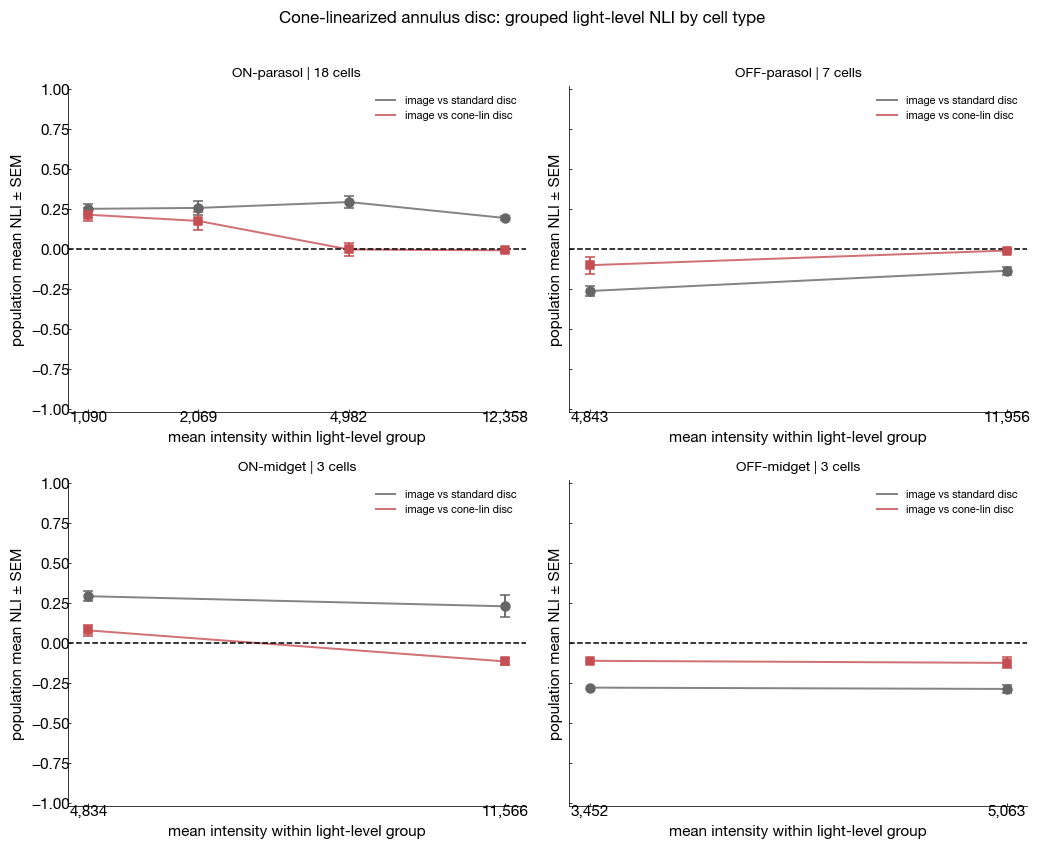

In [6]:
image_nli = led.load_condition_image_nli_summary(
    protocol=ANNULUS_PROTOCOLS)
print(f'{len(image_nli)} cell/image rows from {image_nli.cell_id.nunique()} cells')
image_nli_view = image_nli[[
    'exp_name', 'cell_label', 'cell_type', 'onlineAnalysis', 'protocol',
    'filter_wheel_ndf', 'imageName', 'meanIntensity', 'n_patches',
    'mean_nli_disc', 'mean_nli_cone_disc']]
sc.scroll_table(
    image_nli_view, height=360,
    num_cols=('filter_wheel_ndf', 'meanIntensity', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
light_level_nli = led.summarize_image_nli_light_levels(image_nli)
print(f'{light_level_nli.n_cell_images.sum()} of {len(image_nli)} rows are within 500–20000')
sc.scroll_table(
    light_level_nli, height=300,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_cells',
              'n_cell_images', 'mean_nli_disc', 'sem_nli_disc',
              'mean_nli_cone_disc', 'sem_nli_cone_disc'))
led.plot_image_nli_by_cell_type(
    image_nli, title_prefix='Cone-linearized annulus disc');


### 3a. Pooled patch NLI distributions

Pool every patch NLI from saved annulus-disc HDF5 conditions, without averaging by image or cell.
The first figure compares ordinary and cone-linearized annuli across all saved patches. The second
repeats the normalized 50-bin density and empirical CDF separately for each cell type.


2243 standard and 2243 cone-lin patch NLIs from 2266 saved rows and 31 cells


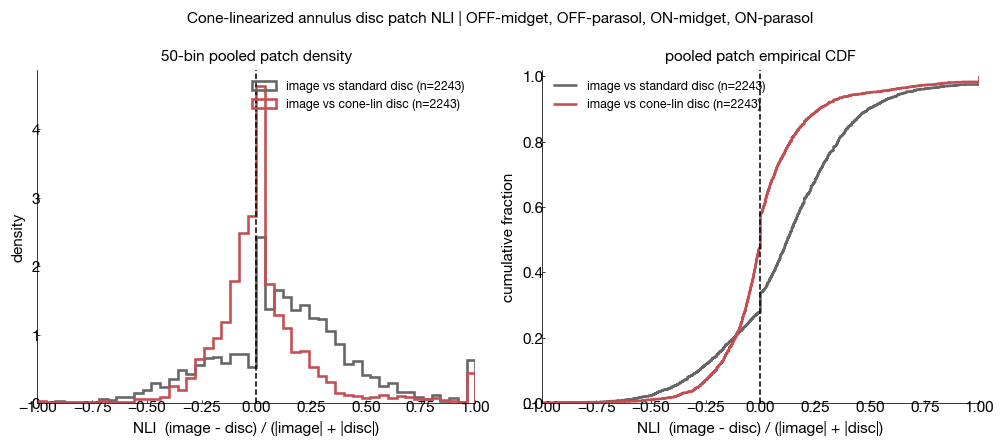

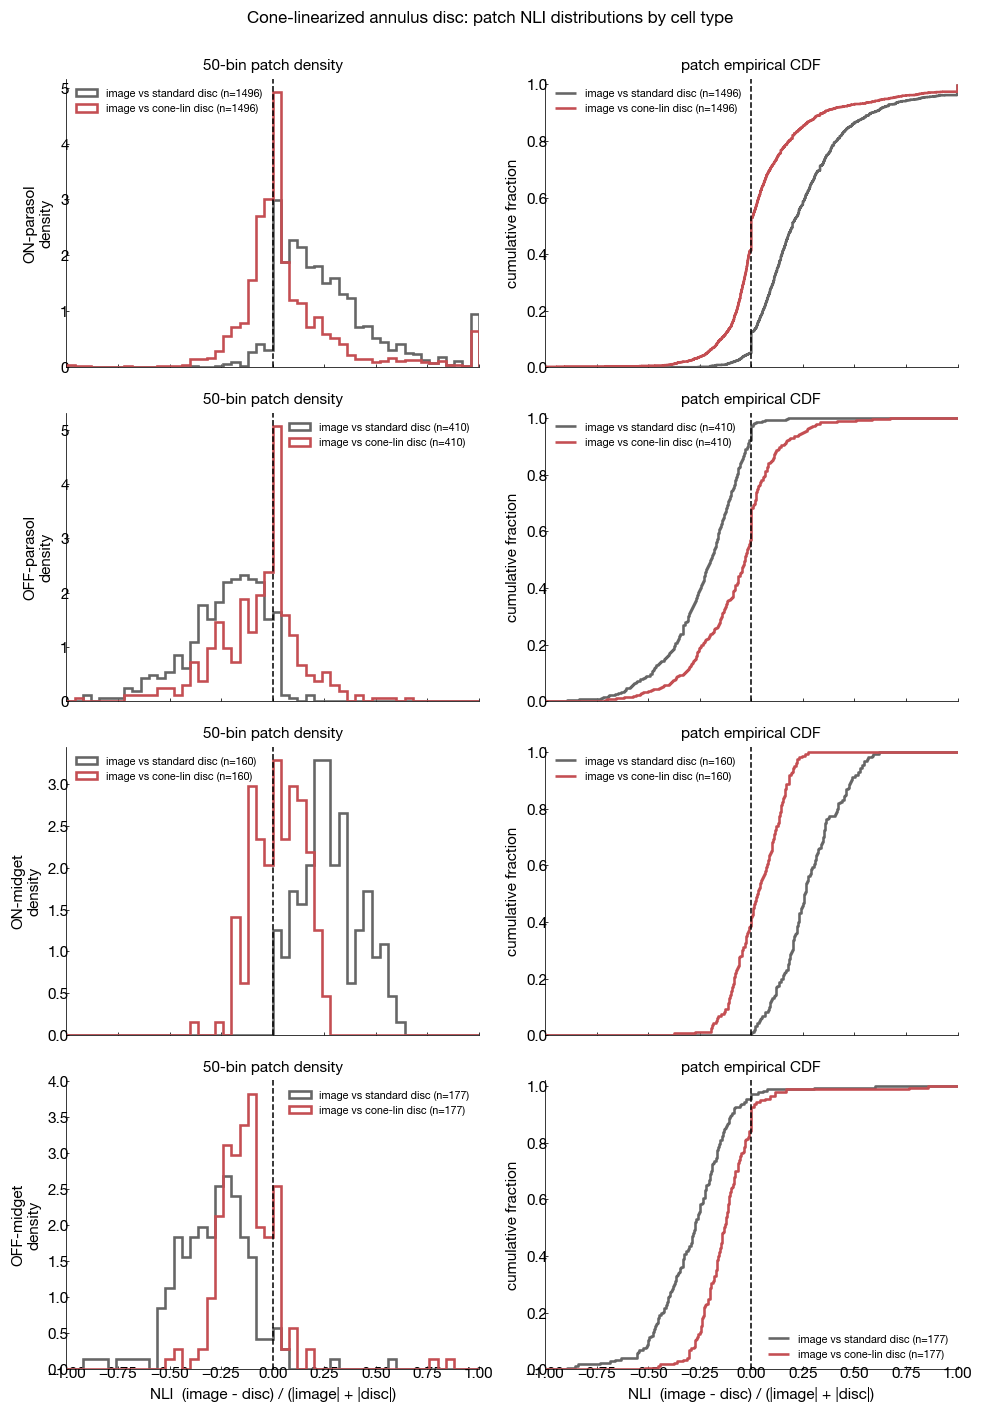

In [7]:
patch_nli = led.load_condition_patch_nli(
    protocol=ANNULUS_PROTOCOLS)
finite_patch_nli = np.isfinite(
    patch_nli[['nli_disc', 'nli_cone_disc']]).sum()
print(f"{finite_patch_nli['nli_disc']} standard and "
      f"{finite_patch_nli['nli_cone_disc']} cone-lin patch NLIs from "
      f'{len(patch_nli)} saved rows and {patch_nli.cell_id.nunique()} cells')
led.plot_pooled_patch_nli_distributions(
    patch_nli, bins=50, title_prefix='Cone-linearized annulus disc');
led.plot_patch_nli_distributions_by_cell_type(
    patch_nli, bins=50, title_prefix='Cone-linearized annulus disc');


### 3b. Cell-level averages by light level and paired high-light comparison

For each cell, pool all patches across all `imageName`s within `[500, 1500)` (~1k) or
`[6000, 20000]` (~10k), then calculate one ordinary-annulus and one cone-linearized mean NLI.
Faint points are those cell means; large points and error bars are population mean ± SEM
across cells, so a cell with more patches does not get extra population weight. Finally, for
each cell type, the paired plot pools every patch at 7000 R* and above into one ordinary-annulus
mean and one cone-linearized-annulus mean per cell, then joins those two values with a line.


cell_type,cell_id,exp_name,cell_label,light_level,light_min,light_max,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc
OFF-parasol,2026-04-24_E/Cell4,2026-04-24_E,Cell4,~10k,6000.0,20000.0,8044.318206118542,1,30,-0.042114999566419016,0.02315933461387802
OFF-parasol,2026-08-18_G/Cell4,2026-08-18_G,Cell4,~10k,6000.0,20000.0,12934.211990066218,4,40,-0.16027031078489495,-0.01848949870578028
ON-midget,2026-08-18_G_2/Cell8,2026-08-18_G_2,Cell8,~10k,6000.0,20000.0,11566.062806427644,4,40,0.22876100432288626,-0.11558391566477924
ON-parasol,2026-05-08_G/Cell2,2026-05-08_G,Cell2,~1k,500.0,1500.0,1049.4478423836622,4,73,0.3343863432157502,0.38754406205269815
ON-parasol,2026-08-12_G/Cell1,2026-08-12_G,Cell1,~1k,500.0,1500.0,1111.787170489064,8,80,0.46651422527335384,0.4893639244493997
ON-parasol,2026-08-12_G_2/Cell4,2026-08-12_G_2,Cell4,~1k,500.0,1500.0,1128.0329932323639,7,70,0.2181217728169829,0.12383612930876069
ON-parasol,2026-08-18_G/Cell1,2026-08-18_G,Cell1,~1k,500.0,1500.0,1114.3499571916573,5,50,0.16649731531559822,0.03226210601292186
ON-parasol,2026-08-18_G/Cell2,2026-08-18_G,Cell2,~1k,500.0,1500.0,1061.7363071574637,5,50,0.13870143631419396,0.0816092857084472
ON-parasol,2026-08-18_G_2/Cell5,2026-08-18_G_2,Cell5,~1k,500.0,1500.0,1088.022477967232,5,50,0.13062885856708964,0.13487862030327516
ON-parasol,2026-08-18_G_2/Cell7,2026-08-18_G_2,Cell7,~1k,500.0,1500.0,874.5468958052282,1,10,0.08243861830082026,0.011879196200624775


cell_type,cell_id,exp_name,cell_label,min_intensity,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc
OFF-parasol,2026-04-24_E/Cell4,2026-04-24_E,Cell4,7000.0,8044.318206118542,1,30,-0.042114999566419016,0.02315933461387802
OFF-parasol,2026-08-18_G/Cell4,2026-08-18_G,Cell4,7000.0,12934.211990066218,4,40,-0.16027031078489495,-0.01848949870578028
ON-midget,2026-08-18_G_2/Cell8,2026-08-18_G_2,Cell8,7000.0,11566.062806427644,4,40,0.22876100432288626,-0.11558391566477924
ON-parasol,2026-08-12_G/Cell1,2026-08-12_G,Cell1,7000.0,12906.641937333197,12,120,0.24651875073921853,-3.0452442259994393e-05
ON-parasol,2026-08-12_G/Cell3,2026-08-12_G,Cell3,7000.0,12319.38663141174,6,60,0.28728675911809154,0.050626193180236166
ON-parasol,2026-08-12_G_2/Cell4,2026-08-12_G_2,Cell4,7000.0,12092.626789499825,7,70,0.22475608333049285,-0.00045017275519135974
ON-parasol,2026-08-18_G/Cell1,2026-08-18_G,Cell1,7000.0,11863.870387284838,3,30,0.17083179843444882,0.007385646725248178
ON-parasol,2026-08-18_G/Cell2,2026-08-18_G,Cell2,7000.0,12219.544614945647,5,50,0.14646303347114592,-0.028529033696905234
ON-parasol,2026-08-18_G_2/Cell5,2026-08-18_G_2,Cell5,7000.0,11799.812130595716,5,50,0.11309662904579458,-0.03295194334525486
ON-parasol,2026-08-18_G_2/Cell6,2026-08-18_G_2,Cell6,7000.0,12693.3434206968,4,40,0.11012661241221215,-0.05925770474671179


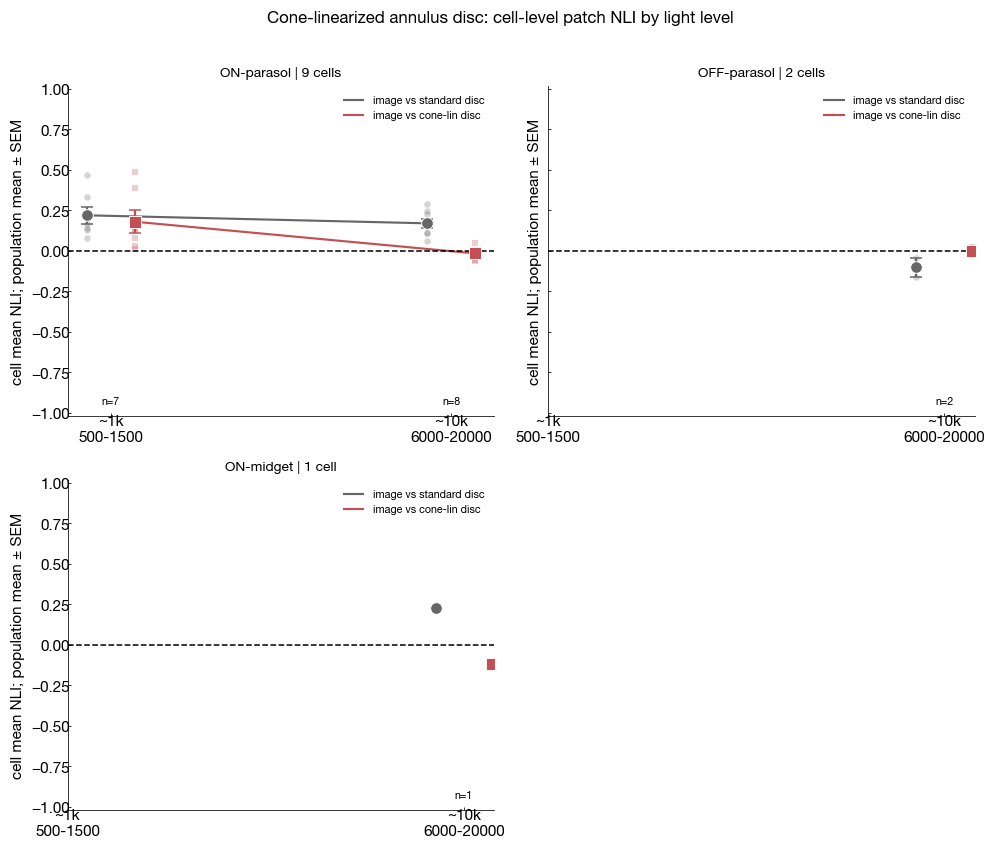

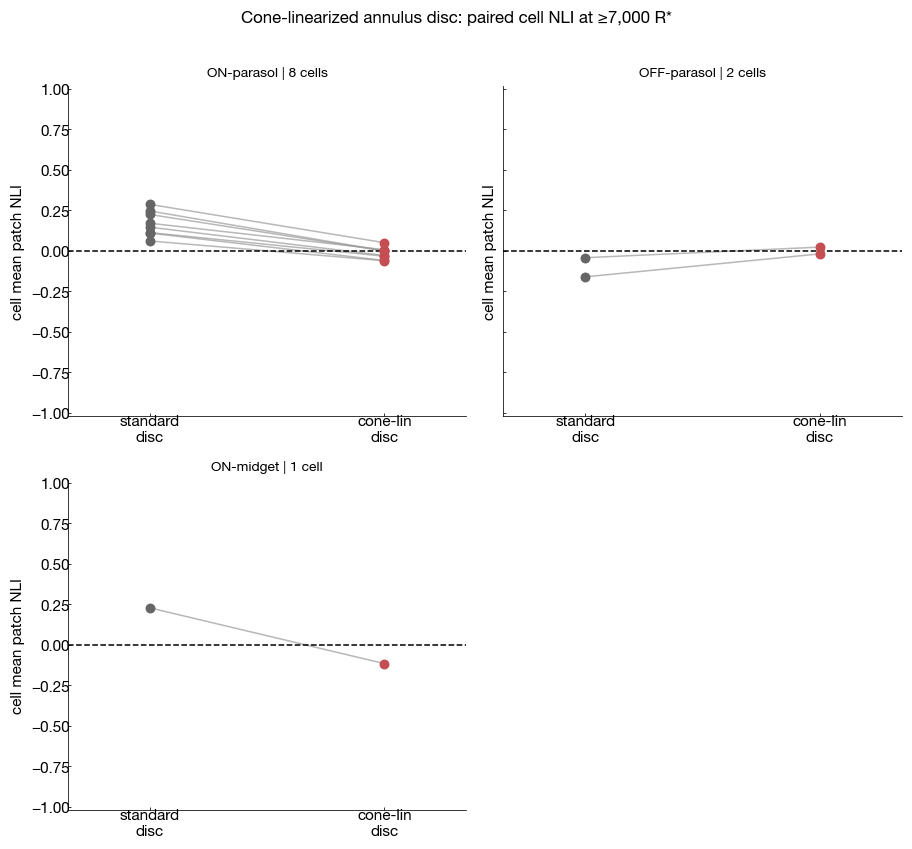

In [8]:
cell_light_nli = led.summarize_cell_patch_nli_light_levels(patch_nli)
sc.scroll_table(
    cell_light_nli, height=320,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_images',
              'n_patches', 'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_by_light(
    cell_light_nli, title_prefix='Cone-linearized annulus disc');
high_light_cell_nli = led.summarize_cell_patch_nli_above(
    patch_nli, min_intensity=7000)
sc.scroll_table(
    high_light_cell_nli, height=300,
    num_cols=('min_intensity', 'meanIntensity', 'n_images', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_paired_above(
    high_light_cell_nli, min_intensity=7000,
    title_prefix='Cone-linearized annulus disc');


### 3c. Export MATLAB population files by cell type

Write one `*LinEquivAnnulusDisc.mat` file per cell type using the same `collectedResults`
cell-array and nested `results` struct layout as `OffParasolLinEquiv.mat`. Each cell-array
element is one unique date/cell × FilterWheel (`nd`) × `imageID` condition. The original 13
fields are retained, with scalar `maxIntensity` and `meanIntensity` appended. Because the
reference schema has no recording-mode field, this export explicitly uses extracellular
conditions only. Any old comma-separated intensity metadata is corrected to the larger value
before export and printed for manual review. The final table counts exported condition entries,
unique cells, and experiment dates from rig E (`fred_data`) and rig G (`chris_data`), both
overall and within each cell type.


In [ ]:
matlab_exports = led.export_annulus_disc_population_mat_files(
    online_analysis='extracellular')
pd.DataFrame([
    {'cell_type': cell_type, 'file': str(path)}
    for cell_type, path in matlab_exports.items()
])
rig_summary = led.summarize_matlab_export_rigs(matlab_exports)
sc.scroll_table(
    rig_summary, height=300,
    num_cols=('condition_entries', 'unique_cells', 'experiment_dates'))

## 4. Inspect selected date metadata (optional)

This optional section uses the date already loaded in Section 2 and groups its recordings by
cell, resolved recording mode, annulus-disc site, and light setting. It is not required for the
single-cell or population analyses above.

In [ ]:
groups = led.group_blocks(selected_blocks)


### 4a. Preview recorded stimuli

This optional visualization uses the date already loaded in Section 2. The dropdown contains
every recorded `imageName` for that date; choosing one redraws several recorded patches as a
tilted flash sequence. Each triplet proceeds from natural-image annulus to linear-equivalent
annulus to cone-linearized annulus,
and the diagonal time arrow shows the repeated presentation order. Spatial x/y arrows are shown
on the first stimulus plane and follow its tilted edges. As in the original protocol, the full
canvas and masked regions remain at the recorded `backgroundIntensity`; only the annulus changes
between the natural-image patch, linear-equivalent intensity, and cone-linearized intensity. The
center spot is overlaid on every flash at `backgroundIntensity × (1 + centerSpotContrast)`. All
stimuli use a common grey scale. The image is loaded from the van Hateren resources in the turner
package the same way `NaturalImageFlashProtocol.m` does — big-endian `.iml`, rescaled so the
brightest pixel is 1, at 6.6 µm per image pixel.

A useful check that the geometry is right: the mean intensity inside the aperture should land on
the recorded `equivalentIntensity`, since that is what the equivalent disc is defined to be.

In [ ]:
image_example = led.stimulus_example_widget(selected_blocks, sequence_length=4)
image_example

## 5. Rig maxIntensity and NDF configuration check

This metadata-only QC reverses both attenuation sources: `estimated rig maxIntensity = recorded maxIntensity × 10**(manual NDF OD + FilterWheel OD)`. Manual Stage labels carry their nominal OD (`EL3 = 3.0`; `EL06 + EL2 = 2.6`), while the numeric FilterWheel value is authoritative and embedded `FW...` labels are shown but not counted twice. The summary reports the median and full observed range; the evidence table retains every manual/filter-wheel combination so calibration changes or bad entries remain visible. No traces or response analysis are loaded.

In [3]:
rig_max_map, rig_ndf_evidence = led.estimate_rig_max_intensity(
    protocols=('LinearEquivalentAnnulus',))

Formula: recorded maxIntensity × 10^(manual NDF OD + FilterWheel OD)
ALERT: 175 block(s) could not be estimated because manual NDF, wheel NDF, or maxIntensity was unavailable.
ALERT: rig G, EL03, EL2, FW0 spans 3.791e+06–1.23706e+07; check its blocks.

Rig maxIntensity map (median with full observed range):


rig,data_source,estimated_rig_maxIntensity,estimate_min,estimate_max,manual_ndfs,filter_wheel_ndfs,blocks,experiment_dates
E,fred_data,30000000.0,25000000.0,30000000.0,EL3,0,108,13
G,chris_data,30256144.962065797,3790998.3984408695,30654252.132619295,"EL03, EL2 | EL06, EL2 | EL2","0, 0.5, 1",150,9



Evidence by manual-NDF and FilterWheel combination:


rig,data_source,manual_ndfs,manual_ndf_od,filter_wheel_ndf,recorded_maxIntensity,estimated_rig_maxIntensity,estimate_min,estimate_max,blocks,experiment_dates,status
B,other,(not recorded),,0.0,,,,,96,8,manual NDF not recorded
E,fred_data,(not recorded),,0.0,30000,,,,6,2,manual NDF not recorded
E,fred_data,EL3,3.0,0.0,"25000, 30000",30000000.0,25000000.0,30000000.0,114,14,
G,chris_data,(not recorded),,0.0,,,,,7,2,manual NDF not recorded
G,chris_data,(not recorded),,2.0,,,,,4,1,manual NDF not recorded
G,chris_data,"EL03, EL2",2.3,0.0,"19000, 61000, 61500, 62000",12171100.12131016,3790998.3984408695,12370626.352807049,10,2,inconsistent estimates (>25% spread)
G,chris_data,"EL03, EL2",2.3,0.5,19000,11988189.545123667,11988189.545123667,11988189.545123667,10,2,
G,chris_data,"EL03, EL2",2.3,1.0,"6100, 6200",12370626.352807049,12171100.121310161,12370626.352807049,9,2,
G,chris_data,"EL06, EL2",2.6,0.0,"75000, 77000",30654252.132619295,29858037.7915123,30654252.132619295,63,6,
G,chris_data,"EL06, EL2",2.6,0.5,24000,30214209.88306002,30214209.88306002,30214209.88306002,5,1,
